# Milestone 3 — Static batching

The per-step floor is paid per **step**, not per token. Batching splits it.

In [1]:
!git clone https://github.com/Jayaprakash-030/tiny-inference-engine.git
%cd tiny-inference-engine
!pip install -q -e .

Cloning into 'tiny-inference-engine'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 26 (delta 5), reused 26 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 12.61 KiB | 12.61 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/tiny-inference-engine
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiny-inference-engine (pyproject.toml) ... done


In [2]:
from engine import load
from engine.batched import (
    batched_generate,
    check_batch_matches_single,
    print_generations,
    sweep,
)
from engine.prompts import BATCH
from engine.results import save

rt = load()
rt.describe()

ImportError: cannot import name 'print_generations' from 'engine.batched' (/content/tiny-inference-engine/engine/batched.py)

### Correctness first

In [3]:
assert check_batch_matches_single(rt, BATCH[:4]), "batching diverged — check padding / position_ids"

batch matches single: True


In [4]:
batched_generate(rt, BATCH[:2], max_new_tokens=16)   # warmup
print("warmup done")

warmup done


### Throughput sweep

In [ ]:
MAX_NEW = 200
out, _, _, _ = batched_generate(rt, BATCH[:4], max_new_tokens=MAX_NEW)
print_generations(rt, BATCH[:4], out, MAX_NEW)

In [5]:
m3 = sweep(rt, sizes=(1, 2, 4, 8, 16, 32), max_new_tokens=200)
save(m3)

batch  1:    23.97 tok/s total,  23.97 per seq,   0.0% wasted, 1.232 GB
batch  2:    48.02 tok/s total,  24.01 per seq,   0.0% wasted, 1.253 GB
batch  4:    96.41 tok/s total,   24.1 per seq,   0.0% wasted, 1.31 GB
batch  8:   209.29 tok/s total,  26.16 per seq,   0.0% wasted, 1.415 GB
batch 16:   378.94 tok/s total,  23.68 per seq,   0.0% wasted, 1.634 GB
batch 32:   750.75 tok/s total,  23.46 per seq,   0.0% wasted, 2.059 GB
appended 6 results to benchmarks/results.json


FileNotFoundError: [Errno 2] No such file or directory: 'benchmarks/plots/m3_batching.png'

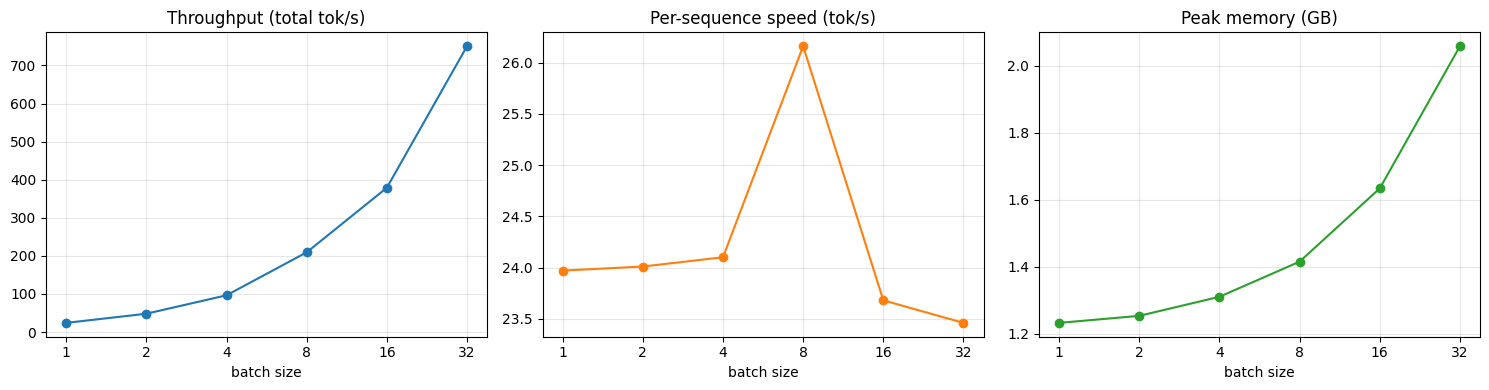

In [6]:
import matplotlib.pyplot as plt

sizes = [r["batch_size"] for r in m3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title, color in [
    (axes[0], "tokens_per_sec", "Throughput (total tok/s)", "tab:blue"),
    (axes[1], "per_seq_tok_per_sec", "Per-sequence speed (tok/s)", "tab:orange"),
    (axes[2], "peak_mem_gb", "Peak memory (GB)", "tab:green"),
]:
    ax.plot(sizes, [r[key] for r in m3], marker="o", color=color)
    ax.set_title(title)
    ax.set_xlabel("batch size")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sizes)
    ax.set_xticklabels(sizes)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("benchmarks/plots/m3_batching.png", dpi=140)
plt.show()

Throughput climbs then flattens — the knee is where the GPU stops being launch-bound.
Per-sequence speed drifts *down*: throughput up, individual latency down, the central
trade in serving.

`wasted_slot_pct` is the argument for milestone 4.